PRÁCTICA 1 - LABORATORIO DE LINGÜÍSTICA
ALUMNO: ABHNER ADHAIR DEHARA ENCINOS

FONÉTICA

In [ ]:
!pip install jupytext --upgrade
!jupytext --set-formats ipynb,py %rehashx

In [91]:
!apt-get update -qq && apt-get install -y espeak -qq
!pip install rich jupytext

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [92]:
import subprocess
import requests as r
import http

# 1. Definición de constantes necesarias
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"
iso_lang_codes = ["es_MX", "en_US"]

# 2. Funciones de descarga y procesamiento
def download_ipa_corpus(iso_lang: str) -> str:
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

def parse_response(response: str) -> dict:
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        # Guardamos la palabra como llave y el fonema como valor
        result[item_list[0]] = item_list[1]
    return result

def get_corpora() -> dict:
    return {
        code: parse_response(download_ipa_corpus(code))
        for code in iso_lang_codes
    }

# 3. Funciones de aproximación
def approximate_phonemes(word, lang_code='es'):
    resultado = subprocess.run(
        ['espeak', '-q', '--ipa', f'-v{lang_code}', word],
        capture_output=True, text=True, check=True
    )
    return resultado.stdout.strip().replace(' ', '')

def get_phonemes_robust(word, corpus, lang_code='es-la'):
    word_lower = word.lower()
    if word_lower in corpus:
        return corpus[word_lower]
    else:
        print(f"[!] La palabra '{word}' no se encontró en el lexicón. Aproximando...")
        return [approximate_phonemes(word_lower, lang_code)]

# 4. EJECUCIÓN: Cargamos los datos en memoria
corpora = get_corpora()
corpus_es = corpora["es_MX"]

In [93]:
palabras_test = ["voynich", "criptografía", "dimensity"]
print("--- PRUEBA DE FONÉTICA ---")
for p in palabras_test:
    # Usamos corpus_es que se definió al final de la celda anterior
    res = get_phonemes_robust(p, corpus_es)
    print(f"Palabra: {p} -> IPA: {res}")

--- PRUEBA DE FONÉTICA ---
[!] La palabra 'voynich' no se encontró en el lexicón. Aproximando...
Palabra: voynich -> IPA: ['boɪnˈitʃ']
Palabra: criptografía -> IPA: /kɾiptoɣɾaˈfia/
[!] La palabra 'dimensity' no se encontró en el lexicón. Aproximando...
Palabra: dimensity -> IPA: ['dˌimɛnsˈiti']


El sistema de búsqueda original depende de un diccionario estático (ipa-dict). Sin embargo, el lenguaje natural contiene palabras fuera del vocabulario (OOV), como neologismos, nombres propios o términos técnicos.

Para resolver este problema se implementó un mecanismo de respaldo (fallback) basado en un modelo de conversión grafema-a-fonema (G2P) utilizando el motor eSpeak. Cuando una palabra no se encuentra en el lexicón, el sistema genera automáticamente una aproximación fonológica en IPA basada en reglas fonológicas.

De esta forma, el sistema se vuelve más robusto, ya que siempre puede producir una transcripción fonológica incluso cuando el diccionario no contiene la palabra consultada.

MORFOLOGÍA

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import requests

print("Librerías listas.")

Librerías listas.


In [95]:
# Descargamos los archivos y forzamos el nombre para que no haya pérdida
!wget -q -O spa.tsv https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/spa.word.train.tsv
!wget -q -O eng.tsv https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/eng.word.train.tsv
!wget -q -O hun.tsv https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/hun.word.train.tsv

print("Archivos descargados: spa.tsv, eng.tsv, hun.tsv")

Archivos descargados: spa.tsv, eng.tsv, hun.tsv


In [96]:
def get_morphstats(segmentations, labels):

    m_per_w, m_lens, cats = [], [], []

    for w, l in zip(segmentations, labels):

        if pd.isna(w) or pd.isna(l):
            continue

        raw_seg = str(w).replace('@@', ' @@ ').split()
        raw_tags = str(l).split()

        segments = [s.replace('@@', '').strip() for s in raw_seg if s.strip() != '@@' and s.strip()]
        tags = [t.strip() for t in raw_tags if t.strip()]

        if len(segments) > 0:

            m_per_w.append(len(segments))

            for s, t in zip(segments, tags):

                m_lens.append(len(s))
                cats.append(t)

    return m_per_w, m_lens, cats

In [97]:
# Cargamos usando sep=None
df_spa = pd.read_csv('spa.tsv', sep='\t', header=None)
df_spa.columns = ['word','seg']
df_spa['label'] = df_spa['seg'].apply(lambda x: " ".join(["000"]*len(str(x).split())))

df_eng = pd.read_csv('eng.tsv', sep='\t', header=None, names=['word', 'seg', 'label']).dropna()
df_hun = pd.read_csv('hun.tsv', sep='\t', header=None, names=['word', 'seg', 'label']).dropna()

# Procesamos
metrics = {
    "Español (Romance)": get_morphstats(df_spa['seg'], df_spa['label']),
    "Inglés (Germánica)": get_morphstats(df_eng['seg'], df_eng['label']),
    "Húngaro (Urálica)": get_morphstats(df_hun['seg'], df_hun['label'])
}

# Guardamos los resultados para las gráficas
results = {}

for name, (m, l, c) in metrics.items():
    total_morfemas = len(c)
    ratio = np.mean(m) if m else 0
    # APLICANDO LA FÓRMULA DE PORCENTAJE
    p_flex = (c.count('100') / total_morfemas * 100) if total_morfemas > 0 else 0
    p_der = (c.count('010') / total_morfemas * 100) if total_morfemas > 0 else 0

    results[name] = {'m_per_w': m, 'm_lens': l, 'cats': c}

    print(f"--- {name} ---")
    print(f"Ratio Morfemas/Palabra: {ratio:.2f}")
    print(f"Porcentaje Flexión (100): {p_flex:.2f}%")
    print(f"Porcentaje Derivación (010): {p_der:.2f}%\n")

--- Español (Romance) ---
Ratio Morfemas/Palabra: 3.24
Porcentaje Flexión (100): 0.00%
Porcentaje Derivación (010): 0.00%

--- Inglés (Germánica) ---
Ratio Morfemas/Palabra: 2.36
Porcentaje Flexión (100): 21.05%
Porcentaje Derivación (010): 0.00%

--- Húngaro (Urálica) ---
Ratio Morfemas/Palabra: 3.25
Porcentaje Flexión (100): 40.77%
Porcentaje Derivación (010): 0.00%



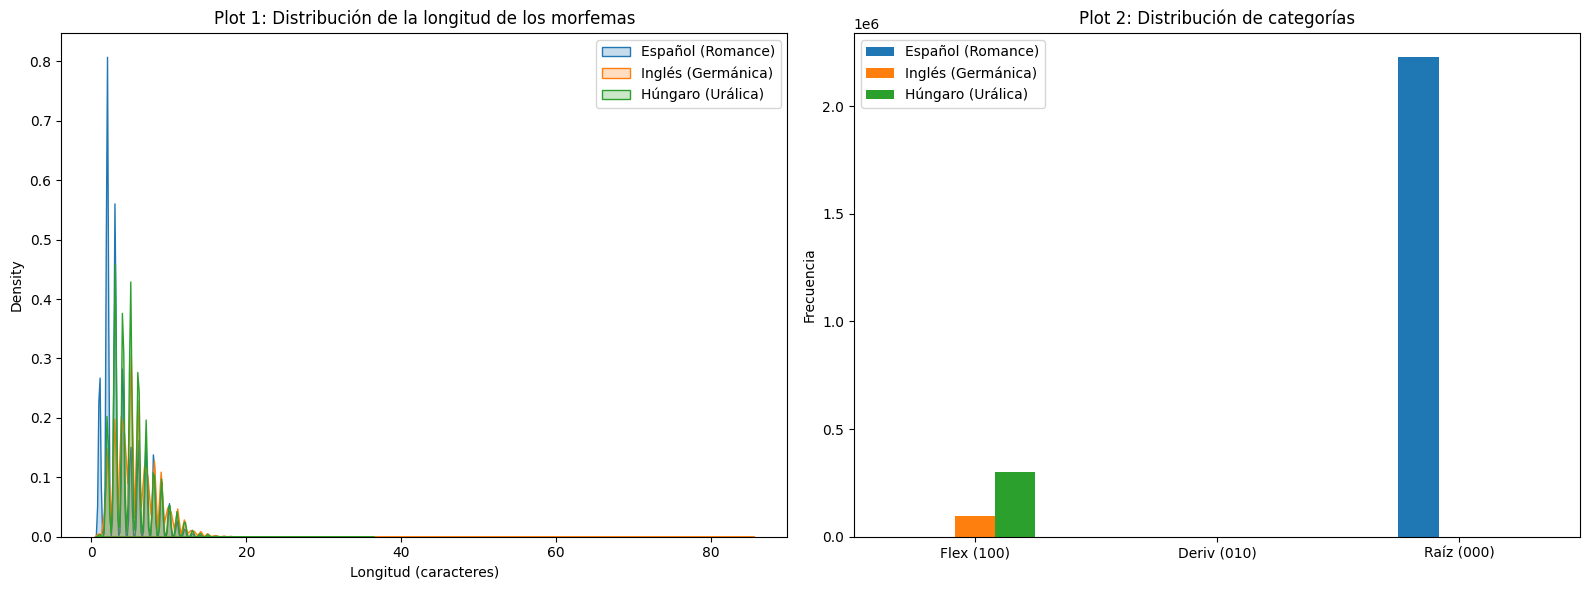

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Longitud de morfemas
for name, data in results.items():
    sns.kdeplot(data['m_lens'], label=name, fill=True, ax=ax1)
ax1.set_title('Plot 1: Distribución de la longitud de los morfemas')
ax1.set_xlabel('Longitud (caracteres)')
ax1.legend()

# Plot 2: Distribución de categorías
cat_labels = ['100', '010', '000']
plot_data = []
for name, data in results.items():
    counts = [data['cats'].count(tag) for tag in cat_labels]
    plot_data.append(counts)

df_plot = pd.DataFrame(plot_data, index=results.keys(), columns=['Flex (100)', 'Deriv (010)', 'Raíz (000)']).T
df_plot.plot(kind='bar', ax=ax2)
ax2.set_title('Plot 2: Distribución de categorías')
ax2.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Los resultados muestran que el húngaro presenta el mayor número promedio de morfemas por palabra (≈3.25) y la mayor proporción de morfemas flexivos, lo que es característico de lenguas aglutinantes.
El inglés presenta un menor uso de morfología flexiva y un número menor de morfemas por palabra (≈2.36), por lo que se aproxima más a un comportamiento aislante.
El español presenta un número relativamente alto de morfemas por palabra, pero en el corpus utilizado no se incluyen etiquetas de flexión, por lo que aparece principalmente como raíz. Tipológicamente, el español se clasifica como una lengua fusional.